ЛР3 ТМО. Канаева Диана ИУ5-62Б

Задачи лабораторной работы:

- обработка пропусков в данных и кодирование категориальных признаков при необходимости
- разделение выборки на обучающую и тестовую с использованием метода train_test_split
- обучение модели ближайших соседей для произвольно заданного гиперпараметра K
- оценка качества модели с помощью подходящих для задачи метрик
- подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV и кросс-валидации, оценка качества оптимальной модели
- сравнение метрик качества исходной и оптимальной моделей

Использован дефолтный датасет load_wine.
   
   

In [2]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, median_absolute_error, r2_score
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(style="ticks")

Подготовка датасета

In [3]:
# https://scikit-learn.org/stable/datasets/index.html#wine-dataset
wine = load_wine()

In [4]:
# Наименования признаков
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [5]:
type(wine.data)

numpy.ndarray

In [6]:
# Наименования значений целевого признака
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [7]:
list(zip(np.unique(wine.target), wine.target_names))

[(np.int64(0), np.str_('class_0')),
 (np.int64(1), np.str_('class_1')),
 (np.int64(2), np.str_('class_2'))]

In [ ]:
# Значения целевого признака
wine.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [ ]:
# Размер выборки
wine.data.shape, wine.target.shape

((178, 13), (178,))

In [ ]:
# Сформируем DataFrame
wine_df = pd.DataFrame(data= np.c_[wine['data'], wine['target']],
                     columns= wine['feature_names'] + ['target'])

In [ ]:
# И выведем его статистические характеристики
wine_df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Разделение выборки на обучающую и тестовую с использованием метода train_test_split

In [ ]:
wine_X_train, wine_X_test, wine_y_train, wine_y_test = train_test_split(
    wine.data, wine.target, test_size=0.3, random_state=1)

In [ ]:
# Размер обучающей выборки
wine_X_train.shape, wine_y_train.shape

((124, 13), (124,))

In [ ]:
# Размер тестовой выборки
wine_X_test.shape, wine_y_test.shape

((54, 13), (54,))

Функция train_test_split разделила исходную выборку таким образом, чтобы в обучающей и тестовой частях сохранились все классы:

In [ ]:
np.unique(wine_y_train)

array([0, 1, 2])

In [ ]:
np.unique(wine_y_test)

array([0, 1, 2])

In [ ]:
def class_proportions(array: np.ndarray) -> Dict[int, Tuple[int, float]]:
    """
    Вычисляет пропорции классов
    array - массив, содержащий метки классов
    """
    # Получение меток классов и количества меток каждого класса
    labels, counts = np.unique(array, return_counts=True)
    # Превращаем количество меток в процент их встречаемости
    # делим количество меток каждого класса на общее количество меток
    counts_perc = counts/array.size
    # Теперь sum(counts_perc)==1.0
    # Создаем результирующий словарь,
    # ключом словаря явлется метка класса,
    # а значением словаря процент встречаемости метки
    res = dict()
    for label, count2 in zip(labels, zip(counts, counts_perc)):
        res[label] = count2
    return res

def print_class_proportions(array: np.ndarray):
    """
    Вывод пропорций классов
    """
    proportions = class_proportions(array)
    if len(proportions)>0:
        print('Метка \t Количество \t Процент встречаемости')
    for i in proportions:
        val, val_perc = proportions[i]
        val_perc_100 = round(val_perc * 100, 2)
        print('{} \t {} \t \t {}%'.format(i, val, val_perc_100))

In [ ]:
# В исходной выборке нет явного дисбаланса классов для целевого признака
print_class_proportions(wine.target)

Метка 	 Количество 	 Процент встречаемости
0 	 59 	 	 33.15%
1 	 71 	 	 39.89%
2 	 48 	 	 26.97%


In [ ]:
# Для обучающей выборки
print_class_proportions(wine_y_train)

Метка 	 Количество 	 Процент встречаемости
0 	 36 	 	 29.03%
1 	 52 	 	 41.94%
2 	 36 	 	 29.03%


In [ ]:
# Для тестовой выборки
print_class_proportions(wine_y_test)

Метка 	 Количество 	 Процент встречаемости
0 	 23 	 	 42.59%
1 	 19 	 	 35.19%
2 	 12 	 	 22.22%


Обучение модели ближайших соседей для произвольно заданного гиперпараметра K

In [ ]:
# 2 ближайших соседа
cl1_1 = KNeighborsClassifier(n_neighbors=2)
cl1_1.fit(wine_X_train, wine_y_train)
target1_1 = cl1_1.predict(wine_X_test)
len(target1_1), target1_1

(54,
 array([0, 1, 2, 1, 0, 1, 2, 0, 1, 1, 0, 1, 1, 0, 2, 1, 1, 0, 1, 0, 0, 1,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 1, 0]))

In [ ]:
# 10 ближайших соседей
cl1_2 = KNeighborsClassifier(n_neighbors=10)
cl1_2.fit(wine_X_train, wine_y_train)
target1_2 = cl1_2.predict(wine_X_test)
len(target1_2), target1_2

(54,
 array([2, 1, 2, 2, 0, 1, 2, 0, 1, 1, 0, 2, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
        2, 0, 2, 1, 0, 0, 0, 2, 1, 2, 1, 0, 2, 1, 1, 2, 1, 0, 0, 1, 1, 2,
        0, 2, 2, 0, 0, 0, 1, 1, 2, 0]))

In [ ]:
# 50 ближайших соседей
cl1_3 = KNeighborsClassifier(n_neighbors=50)
cl1_3.fit(wine_X_train, wine_y_train)
target1_3 = cl1_3.predict(wine_X_test)
len(target1_3), target1_3

(54,
 array([2, 1, 2, 2, 0, 1, 2, 0, 1, 1, 0, 2, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
        2, 0, 2, 1, 0, 0, 0, 2, 1, 2, 1, 0, 2, 1, 1, 2, 1, 0, 0, 1, 1, 2,
        0, 0, 2, 0, 0, 0, 1, 2, 2, 0]))

Оценка качества модели с помощью подходящих для задачи метрик

Метрика Accuracy вычисляет процент (долю в диапазоне от 0 до 1) правильно определенных классов:

In [ ]:
# wine_y_test - эталонное значение классов из исходной (тестовой) выборки
# target* - предсказанное значение классов

# 2 ближайших соседа
accuracy_score(wine_y_test, target1_1)

0.6666666666666666

In [ ]:
# 10 ближайших соседей
accuracy_score(wine_y_test, target1_2)

0.6666666666666666

In [ ]:
# 50 ближайших соседей
accuracy_score(wine_y_test, target1_3)

0.7037037037037037

Точность в случае 50 ближайших соседей составляет 70%, в случае 10 ближайших соседей составляет 67%, в случае 2 ближайших соседей составляет 67%

Метрика Accuracy может показывать точность для различных классов:


In [ ]:
def accuracy_score_for_classes(
    y_true: np.ndarray,
    y_pred: np.ndarray) -> Dict[int, float]:
    """
    Вычисление метрики accuracy для каждого класса
    y_true - истинные значения классов
    y_pred - предсказанные значения классов
    Возвращает словарь: ключ - метка класса,
    значение - Accuracy для данного класса
    """
    # Для удобства фильтрации сформируем Pandas DataFrame
    d = {'t': y_true, 'p': y_pred}
    df = pd.DataFrame(data=d)
    # Метки классов
    classes = np.unique(y_true)
    # Результирующий словарь
    res = dict()
    # Перебор меток классов
    for c in classes:
        # отфильтруем данные, которые соответствуют
        # текущей метке класса в истинных значениях
        temp_data_flt = df[df['t']==c]
        # расчет accuracy для заданной метки класса
        temp_acc = accuracy_score(
            temp_data_flt['t'].values,
            temp_data_flt['p'].values)
        # сохранение результата в словарь
        res[c] = temp_acc
    return res

def print_accuracy_score_for_classes(
    y_true: np.ndarray,
    y_pred: np.ndarray):
    """
    Вывод метрики accuracy для каждого класса
    """
    accs = accuracy_score_for_classes(y_true, y_pred)
    if len(accs)>0:
        print('Метка \t Accuracy')
    for i in accs:
        print('{} \t {}'.format(i, accs[i]))

In [ ]:
# 2 ближайших соседа
print_accuracy_score_for_classes(wine_y_test, target1_1)

Метка 	 Accuracy
0 	 0.9130434782608695
1 	 0.7894736842105263
2 	 0.0


Accuracy для классов 0 и 1 составляет 90% и 78%, но класс 2 не угадывается вообще

In [ ]:
# 10 ближайших соседей
print_accuracy_score_for_classes(wine_y_test, target1_2)

Метка 	 Accuracy
0 	 0.782608695652174
1 	 0.6842105263157895
2 	 0.4166666666666667


Accuracy для класса 0 и 1 составляет 78% и 68%, но для класса 2 всего 42%

In [ ]:
# 50 ближайших соседей
print_accuracy_score_for_classes(wine_y_test, target1_3)

Метка 	 Accuracy
0 	 0.8260869565217391
1 	 0.6842105263157895
2 	 0.5


Accuracy для классов 0, 1, 2 составляет 82%, 68%, 50% соответственно

В случае дисбаланса классов для бинарной классификации рекомендуется использовать метрику balanced_accuracy_score:

In [ ]:
# Конвертация целевого признака в бинарный
def convert_target_to_binary(array:np.ndarray, target:int) -> np.ndarray:
    # Если целевой признак совпадает с указанным, то 1 иначе 0
    res = [1 if x==target else 0 for x in array]
    return res

In [ ]:
# Если целевой признак =2,
# то будем считать этот случай 1 в бинарном признаке
bin_wine_y_train = convert_target_to_binary(wine_y_train, 2)
list(zip(wine_y_train, bin_wine_y_train))[:10]

[(1, 0),
 (1, 0),
 (0, 0),
 (1, 0),
 (2, 1),
 (1, 0),
 (1, 0),
 (0, 0),
 (2, 1),
 (1, 0)]

In [ ]:
bin_wine_y_test = convert_target_to_binary(wine_y_test, 2)
list(zip(wine_y_test, bin_wine_y_test))[:10]

[(2, 1),
 (1, 0),
 (0, 0),
 (1, 0),
 (0, 0),
 (2, 1),
 (1, 0),
 (0, 0),
 (2, 1),
 (1, 0)]

In [ ]:
# Конвертация предсказанных признаков
bin_target1_1 = convert_target_to_binary(target1_1, 2)
bin_target1_2 = convert_target_to_binary(target1_2, 2)
bin_target1_3 = convert_target_to_binary(target1_3, 2)

In [ ]:
balanced_accuracy_score(bin_wine_y_test, bin_target1_1)

0.4642857142857143

In [ ]:
balanced_accuracy_score(bin_wine_y_test, bin_target1_2)

0.5892857142857143

In [ ]:
balanced_accuracy_score(bin_wine_y_test, bin_target1_3)

0.6428571428571428

Матрица ошибок представляет количество верно и ошибочно классифицированных данных:


In [ ]:
confusion_matrix(bin_wine_y_test, bin_target1_1, labels=[0, 1])

array([[39,  3],
       [12,  0]])

In [ ]:
tn, fp, fn, tp = confusion_matrix(bin_wine_y_test, bin_target1_1).ravel()
tn, fp, fn, tp

(39, 3, 12, 0)

In [ ]:
# Пример для небинарной классификации
confusion_matrix(wine_y_test, target1_1, labels=[0, 1, 2])

array([[21,  1,  1],
       [ 2, 15,  2],
       [ 1, 11,  0]])

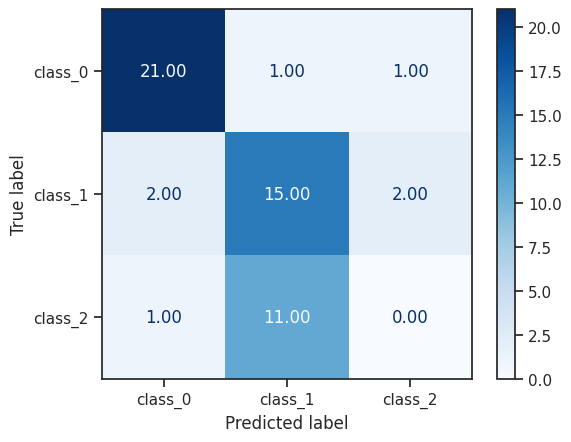

In [ ]:
conf_matrix = confusion_matrix(wine_y_test, cl1_1.predict(wine_X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix,
                              display_labels=wine.target_names)
disp.plot(cmap=plt.cm.Blues, values_format='.2f')
plt.show()

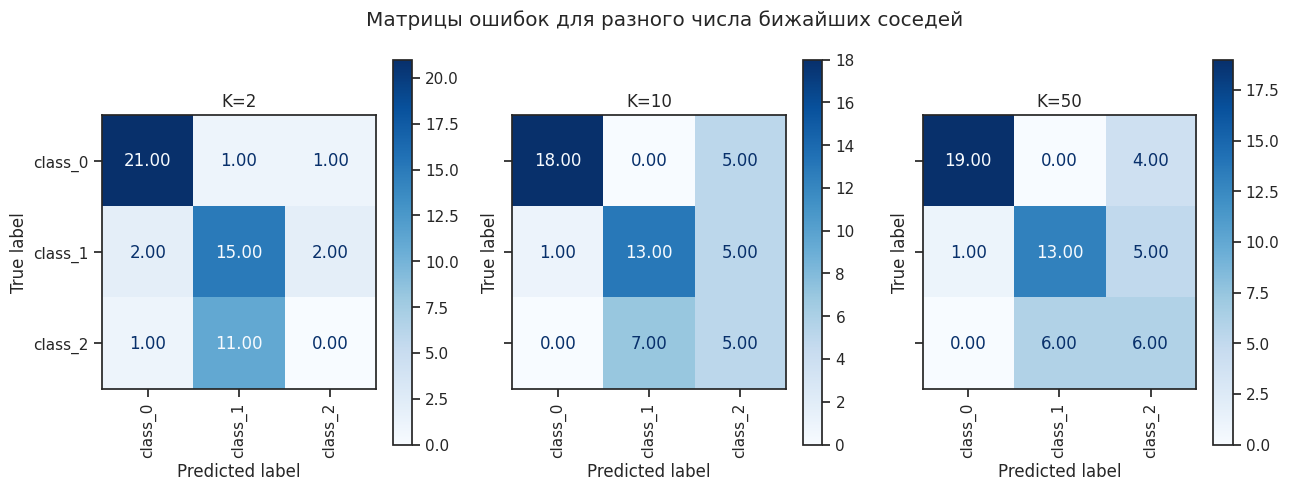

In [ ]:
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(15,5))

confusion_matrix1 = confusion_matrix(wine_y_test, cl1_1.predict(wine_X_test))
disp1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix1, display_labels=wine.target_names)
disp1.plot(cmap=plt.cm.Blues, ax=ax[0], xticks_rotation='vertical', values_format='.2f')
disp1.ax_.set_title('K=2')

confusion_matrix2 = confusion_matrix(wine_y_test, cl1_2.predict(wine_X_test))
disp2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix2, display_labels=wine.target_names)
disp2.plot(cmap=plt.cm.Blues, ax=ax[1], xticks_rotation='vertical', values_format='.2f')
disp2.ax_.set_title('K=10')

confusion_matrix3 = confusion_matrix(wine_y_test, cl1_3.predict(wine_X_test))
disp2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix3, display_labels=wine.target_names)
disp2.plot(cmap=plt.cm.Blues, ax=ax[2], xticks_rotation='vertical', values_format='.2f')
disp2.ax_.set_title('K=50')

fig.suptitle('Матрицы ошибок для разного числа бижайших соседей')

plt.show()

- Метрика precision:

Можно переводить как точность, но такой перевод совпадает с переводом метрики "accuracy".

$precision = \frac{TP}{TP+FP}$

Доля верно предсказанных классификатором положительных объектов, из всех объектов, которые классификатор верно или неверно определил как положительные

- Метрика recall (полнота):

$recall = \frac{TP}{TP+FN}$

Доля верно предсказанных классификатором положительных объектов, из всех действительно положительных объектов

- Метрика accuracy:

Уже знакомая метрика accuracy может быть записана с помощью следующей формулы:

$accuracy = \frac{TP+TN}{TP+TN+FP+FN}$

Доля верно предсказанных классификатором положительных и отрицательных объектов

По умолчанию метрики считаются для 1 класса бинарной классификации

In [ ]:
# Для 2 ближайших соседей
precision_score(bin_wine_y_test, bin_target1_1), recall_score(bin_wine_y_test, bin_target1_1)

(0.0, 0.0)

In [ ]:
# Для 10 ближайших соседей
precision_score(bin_wine_y_test, bin_target1_2), recall_score(bin_wine_y_test, bin_target1_2)

(0.3333333333333333, 0.4166666666666667)

In [ ]:
# Для 50 ближайших соседей
precision_score(bin_wine_y_test, bin_target1_3), recall_score(bin_wine_y_test, bin_target1_3)

(0.4, 0.5)

Параметр average

In [ ]:
# Параметры TP, TN, FP, FN считаются как сумма по всем классам
precision_score(wine_y_test, target1_1, average='micro')

0.6666666666666666

In [ ]:
# Параметры TP, TN, FP, FN считаются отдельно для каждого класса
# и берется среднее значение, дисбаланс классов не учитывается.
precision_score(wine_y_test, target1_1, average='macro')

0.47685185185185186

In [ ]:
# Параметры TP, TN, FP, FN считаются отдельно для каждого класса
# и берется средневзвешенное значение, дисбаланс классов учитывается
# в виде веса классов (вес - количество истинных значений каждого класса).
precision_score(wine_y_test, target1_1, average='weighted')

0.5681584362139918

Функция classification_report позволяет выводить значения точности, полноты и F-меры для всех классов выборки.

In [ ]:
classification_report(wine_y_test, target1_1,
                      target_names=wine.target_names, output_dict=True)

{'class_0': {'precision': 0.875,
  'recall': 0.9130434782608695,
  'f1-score': 0.8936170212765957,
  'support': 23},
 'class_1': {'precision': 0.5555555555555556,
  'recall': 0.7894736842105263,
  'f1-score': 0.6521739130434783,
  'support': 19},
 'class_2': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 12},
 'accuracy': 0.6666666666666666,
 'macro avg': {'precision': 0.47685185185185186,
  'recall': 0.5675057208237986,
  'f1-score': 0.515263644773358,
  'support': 54},
 'weighted avg': {'precision': 0.5681584362139918,
  'recall': 0.6666666666666666,
  'f1-score': 0.6100832562442183,
  'support': 54}}

ROC-кривая и ROC AUC используется для оценки качества бинарной классификации.

Основана на вычислении следующих характеристик:

$TPR = \frac{TP}{TP+FN}$ - True Positive Rate, откладывается по оси ординат.

$FPR = \frac{FP}{FP+TN}$ - False Positive Rate, откладывается по оси абсцисс.

$TPR$ содержит в знаменателе количество истинных 1.

$FPR$ содержит в знаменателе количество истинных 0.

Идеальная ROC-кривая проходит через точки (0,0)-(0,1)-(1,1), то есть через верхний левый угол графика. Чем сильнее отклоняется кривая от верхнего левого угла графика, тем хуже качество классификации.

В качестве количественной метрики используется площадь под кривой - ROC AUC (Area Under the Receiver Operating Characteristic Curve). Чем ниже проходит кривая, тем меньше ее площадь и тем хуже качество классификатора.

In [ ]:
# Обучим модели на задаче бинарной классифкации, чтобы получить вероятности классов
bin_cl1_1 = KNeighborsClassifier(n_neighbors=2)
bin_cl1_1.fit(wine_X_train, bin_wine_y_train)
# предскажем метки классов
bin_cl1_1.predict(wine_X_test)

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
# Классы возвращаются в следующем порядке
bin_cl1_1.classes_

array([0, 1])

In [ ]:
proba_target1_1 = bin_cl1_1.predict_proba(wine_X_test)
true_proba_target1_1 = proba_target1_1[:,1]
fpr, tpr, thresholds = roc_curve(bin_wine_y_test, true_proba_target1_1, pos_label=1)

In [ ]:
# Отрисовка ROC-кривой
def draw_roc_curve(y_true, y_score, pos_label, average):
    fpr, tpr, thresholds = roc_curve(y_true, y_score,
                                     pos_label=pos_label)
    roc_auc_value = roc_auc_score(y_true, y_score, average=average)
    plt.figure()
    lw = 2
    plt.plot(fpr, tpr, color='darkorange',
             lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_value)
    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic example')
    plt.legend(loc="lower right")
    plt.show()

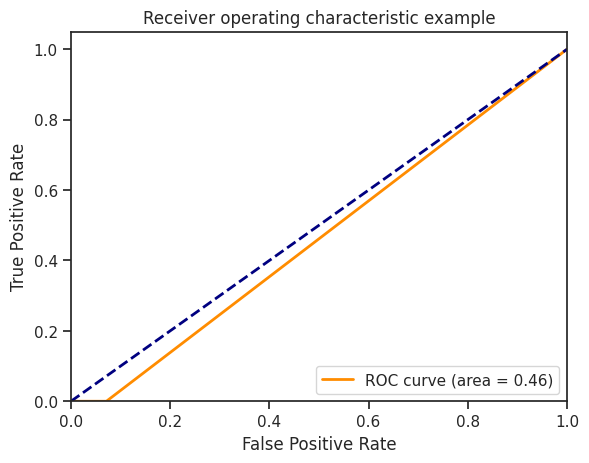

In [ ]:
# Для 2 ближайших соседей
draw_roc_curve(bin_wine_y_test, bin_target1_1, pos_label=1, average='micro')

In [ ]:
bin_cl1_2 = KNeighborsClassifier(n_neighbors=10)
bin_cl1_2.fit(wine_X_train, bin_wine_y_train)
proba_target2_1 = bin_cl1_2.predict_proba(wine_X_test)
true_proba_target2_1 = proba_target2_1[:,1]
roc_curve_k10_res = roc_curve(bin_wine_y_test, true_proba_target2_1, pos_label=1)

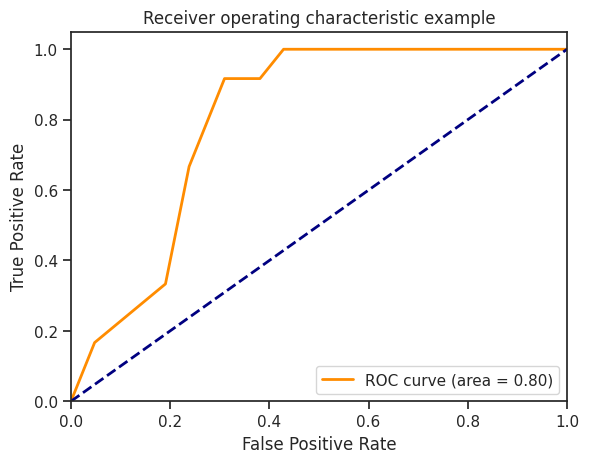

In [ ]:
draw_roc_curve(bin_wine_y_test, true_proba_target2_1, pos_label=1, average='micro')

Подбор гиперпараметра K с использованием GridSearchCV и RandomizedSearchCV и кросс-валидации, оценка качества оптимальной модели

In [ ]:
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.model_selection import KFold, RepeatedKFold, LeaveOneOut, LeavePOut, ShuffleSplit, StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import learning_curve, validation_curve

In [ ]:
n_range = np.array(range(5,55,5))
tuned_parameters = [{'n_neighbors': n_range}]
tuned_parameters

[{'n_neighbors': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])}]

In [ ]:
%%time
clf_gs = GridSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='accuracy')
clf_gs.fit(wine_X_train, wine_y_train)

CPU times: user 287 ms, sys: 8.67 ms, total: 296 ms
Wall time: 308 ms


GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])}],
             scoring='accuracy')

In [ ]:
clf_gs.cv_results_

{'mean_fit_time': array([0.00091114, 0.00076299, 0.00076551, 0.00080762, 0.00077248,
        0.00076938, 0.00079699, 0.00080385, 0.00086813, 0.00057759]),
 'std_fit_time': array([2.59306335e-04, 3.20945061e-05, 3.52986416e-05, 2.20227540e-05,
        2.65170340e-05, 1.12951038e-05, 1.77601199e-05, 8.08222244e-05,
        1.49325985e-04, 1.87419448e-05]),
 'mean_score_time': array([0.00424414, 0.0035099 , 0.00387015, 0.00374413, 0.00392079,
        0.00368686, 0.00388489, 0.00375466, 0.0041451 , 0.01417146]),
 'std_score_time': array([1.15833001e-03, 6.58195241e-05, 5.24811590e-04, 2.08980651e-04,
        5.21709690e-04, 8.66520050e-05, 2.76097222e-04, 1.21103534e-04,
        5.66914651e-04, 1.93369130e-02]),
 'param_n_neighbors': masked_array(data=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
              mask=[False, False, False, False, False, False, False, False,
                    False, False],
        fill_value='?',
             dtype=object),
 'params': [{'n_neighbors': 5},
  {'n_

In [ ]:
# Лучшая модель
clf_gs.best_estimator_

KNeighborsClassifier(n_neighbors=20)

In [ ]:
# Лучшее значение метрики и параметра
clf_gs.best_score_, clf_gs.best_params_

(0.7340000000000001, {'n_neighbors': 20})

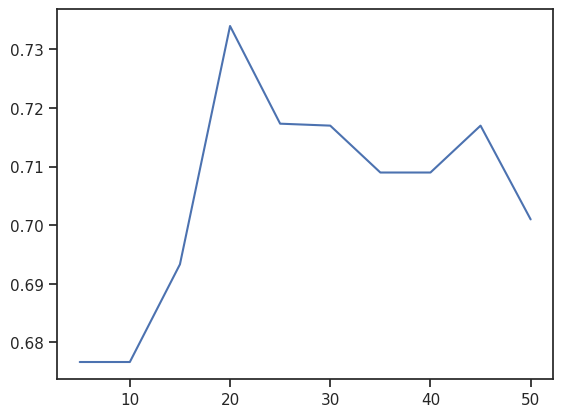

In [ ]:
# Изменение качества на тестовой выборке в зависимости от К-соседей
plt.plot(n_range, clf_gs.cv_results_['mean_test_score'])

In [ ]:
%%time
clf_rs = RandomizedSearchCV(KNeighborsClassifier(), tuned_parameters, cv=5, scoring='accuracy')
clf_rs.fit(wine_X_train, wine_y_train)

CPU times: user 460 ms, sys: 5.44 ms, total: 466 ms
Wall time: 726 ms


RandomizedSearchCV(cv=5, estimator=KNeighborsClassifier(),
                   param_distributions=[{'n_neighbors': array([ 5, 10, 15, 20, 25, 30, 35, 40, 45, 50])}],
                   scoring='accuracy')

In [ ]:
# Лучшее значение метрики и параметра
clf_rs.best_score_, clf_rs.best_params_

(0.7340000000000001, {'n_neighbors': 20})

In [ ]:
# Для сравнения:
clf_gs.best_score_, clf_gs.best_params_

(0.7340000000000001, {'n_neighbors': 20})

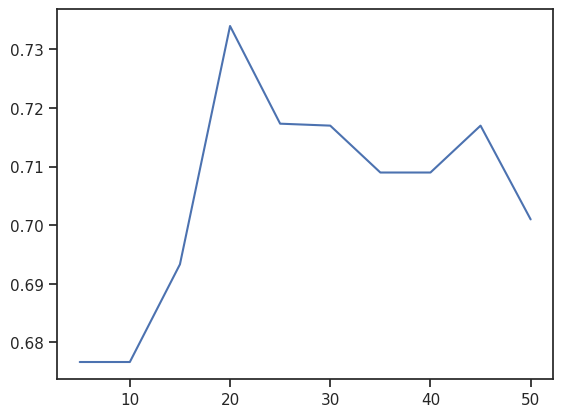

In [ ]:
# Изменение качества на тестовой выборке в зависимости от К-соседей
plt.plot(n_range, clf_rs.cv_results_['mean_test_score'])

K-fold стратегия кросс-валидации

In [ ]:
# Возвращаются индексы элементов
X = ["a", "b", "c"]
kf = KFold(n_splits=3)
for train, test in kf.split(X):
    print("%s %s" % (train, test))

[1 2] [0]
[0 2] [1]
[0 1] [2]


In [ ]:
X = range(12)
kf = KFold(n_splits=3)
for train, test in kf.split(X):
    print("%s %s" % (train, test))


[ 4  5  6  7  8  9 10 11] [0 1 2 3]
[ 0  1  2  3  8  9 10 11] [4 5 6 7]
[0 1 2 3 4 5 6 7] [ 8  9 10 11]


In [ ]:
kf = KFold(n_splits=5)
scores = cross_val_score(KNeighborsClassifier(n_neighbors=2),
                         wine.data, wine.target, scoring='f1_weighted',
                         cv=kf)
scores

array([0.92537313, 0.86969697, 0.77966102, 0.65924812, 0.        ])

In [ ]:
kf = KFold(n_splits=5)
scores = cross_validate(KNeighborsClassifier(n_neighbors=2),
                        wine.data, wine.target, scoring='f1_weighted',
                        cv=kf, return_train_score=True)
scores

{'fit_time': array([0.00145411, 0.00084209, 0.00088882, 0.00082254, 0.00083756]),
 'score_time': array([0.01245832, 0.00524449, 0.00526452, 0.00516701, 0.00531268]),
 'test_score': array([0.92537313, 0.86969697, 0.77966102, 0.65924812, 0.        ]),
 'train_score': array([0.85579923, 0.87555637, 0.87794358, 0.85195658, 0.89135438])}

Leave One Out стратегия кросс-валидации


In [ ]:
X = range(12)
kf = LeaveOneOut()
for train, test in kf.split(X):
    print("%s %s" % (train, test))

[ 1  2  3  4  5  6  7  8  9 10 11] [0]
[ 0  2  3  4  5  6  7  8  9 10 11] [1]
[ 0  1  3  4  5  6  7  8  9 10 11] [2]
[ 0  1  2  4  5  6  7  8  9 10 11] [3]
[ 0  1  2  3  5  6  7  8  9 10 11] [4]
[ 0  1  2  3  4  6  7  8  9 10 11] [5]
[ 0  1  2  3  4  5  7  8  9 10 11] [6]
[ 0  1  2  3  4  5  6  8  9 10 11] [7]
[ 0  1  2  3  4  5  6  7  9 10 11] [8]
[ 0  1  2  3  4  5  6  7  8 10 11] [9]
[ 0  1  2  3  4  5  6  7  8  9 11] [10]
[ 0  1  2  3  4  5  6  7  8  9 10] [11]


In [ ]:
# 15 ближайших соседей
cl1_4 = KNeighborsClassifier(n_neighbors=15)
cl1_4.fit(wine_X_train, wine_y_train)
target1_4 = cl1_4.predict(wine_X_test)
len(target1_4), target1_4

(54,
 array([1, 1, 0, 2, 0, 2, 2, 0, 1, 1, 0, 2, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1,
        2, 0, 2, 2, 0, 0, 0, 2, 1, 2, 1, 0, 2, 1, 1, 2, 1, 0, 0, 1, 1, 2,
        0, 0, 2, 0, 0, 0, 1, 1, 1, 0]))

In [ ]:
# 10 ближайших соседей
accuracy_score(wine_y_test, target1_2)

0.6666666666666666

In [ ]:
# 15 ближайших соседей
accuracy_score(wine_y_test, target1_4)

0.7037037037037037

In [ ]:
# 10 ближайших соседей
print_accuracy_score_for_classes(wine_y_test, target1_2)

Метка 	 Accuracy
0 	 0.782608695652174
1 	 0.6842105263157895
2 	 0.4166666666666667


In [ ]:
# 15 ближайших соседей
print_accuracy_score_for_classes(wine_y_test, target1_4)

Метка 	 Accuracy
0 	 0.8695652173913043
1 	 0.6842105263157895
2 	 0.4166666666666667


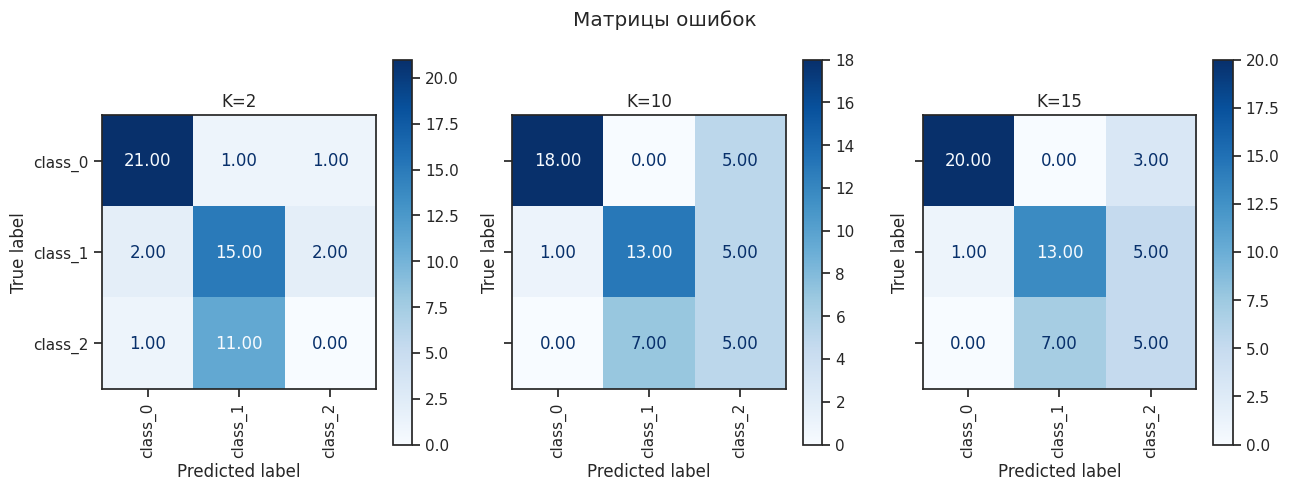

In [ ]:
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(15,5))

confusion_matrix1 = confusion_matrix(wine_y_test, cl1_1.predict(wine_X_test))
disp1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix1, display_labels=wine.target_names)
disp1.plot(cmap=plt.cm.Blues, ax=ax[0], xticks_rotation='vertical', values_format='.2f')
disp1.ax_.set_title('K=2')

confusion_matrix2 = confusion_matrix(wine_y_test, cl1_2.predict(wine_X_test))
disp2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix2, display_labels=wine.target_names)
disp2.plot(cmap=plt.cm.Blues, ax=ax[1], xticks_rotation='vertical', values_format='.2f')
disp2.ax_.set_title('K=10')

confusion_matrix4 = confusion_matrix(wine_y_test, cl1_4.predict(wine_X_test))
disp3 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix4, display_labels=wine.target_names)
disp3.plot(cmap=plt.cm.Blues, ax=ax[2], xticks_rotation='vertical', values_format='.2f')
disp3.ax_.set_title('K=15')

fig.suptitle('Матрицы ошибок')

plt.show()

In [ ]:
# 15 ближайших соседов
bin_cl1_4 = KNeighborsClassifier(n_neighbors=15)
bin_cl1_4.fit(wine_X_train, bin_wine_y_train)
# предскажем метки классов
bin_cl1_4.predict(wine_X_test)

array([0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
bin_target1_4 = convert_target_to_binary(target1_4, 2)

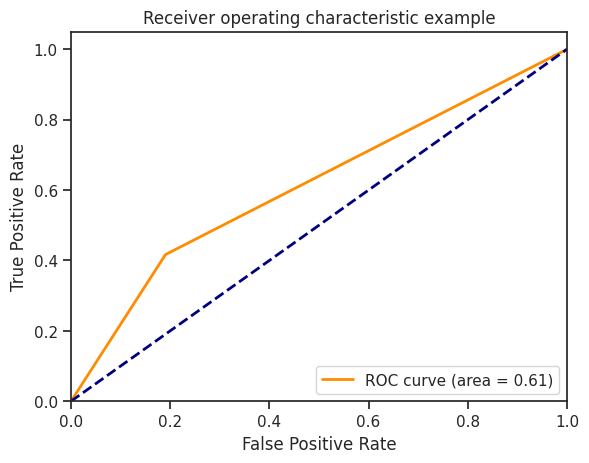

In [ ]:
# Для 15 ближайших соседей
draw_roc_curve(bin_wine_y_test, bin_target1_4, pos_label=1, average='micro')